In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import sparrow as sp
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import matplotlib.pyplot as plt


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
2025-02-06 11:22:46,769 - sparrow.image.pixel_clustering._clustering - WARNING - 'flowsom' not installed, to use 'sp.im.flowsom', please install this library.
2025-02-06 11:22:47,796 - sparrow.table.cell_clustering._clustering - WARNING - 'flowsom' not installed, to use 'sp.tb.flowsom', please install this library.
/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/ann

In [2]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

In [3]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
├── Images
│     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Labels
│     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
│     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
│     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
│     └── 'segmenta

Load in the segmentation mask generated in 4_3

### 1. Generate number of nuclei per 8um bin

In [ ]:
import geopandas as gpd

In [4]:

gdf = sdata.shapes['segmentation_boundaries']
gdf

,geometry,value
1,"POLYGON ((38112 43, 38112 44, 38109 44, 38109 ...",1369.0
2,"POLYGON ((38062 62, 38062 63, 38059 63, 38059 ...",1469.0
3,"POLYGON ((38155 1609, 38155 1610, 38153 1610, ...",2100.0
4,"POLYGON ((38172 1643, 38172 1644, 38169 1644, ...",1956.0
5,"POLYGON ((38200 1655, 38200 1656, 38198 1656, ...",1428.0
...,...,...
193060,"POLYGON ((12231 31606, 12231 31607, 12230 3160...",183979.0
193061,"POLYGON ((12152 31622, 12152 31623, 12151 3162...",184061.0
193062,"POLYGON ((12251 31615, 12251 31616, 12249 3161...",184594.0
193063,"POLYGON ((12143 31637, 12143 31638, 12142 3163...",183328.0


<Axes: >

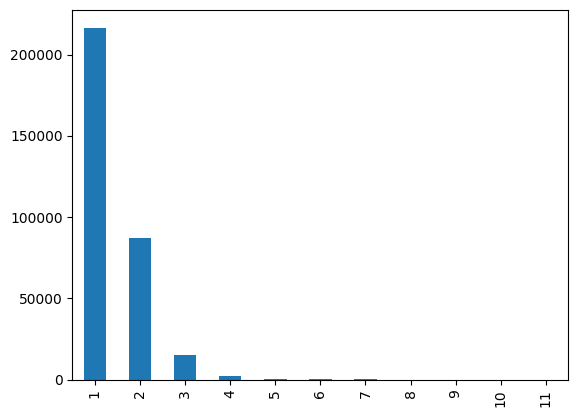

In [5]:
# Get grid shapes from sdata, and add grid_id to the grid shapes
grid_df = sdata.shapes['Visium_HD_Liver_square_008um']
grid_df['grid_id'] = grid_df.index

# Create intersection between grid and nuclei
intersections = gdf.overlay(grid_df, how='intersection')
intersections["nucleus_area"] = intersections.geometry.area  # Calculate intersection area

# Calculate percentage of nucleus area over total grid area
grid_area = grid_df.geometry.area.values[0] # 853
intersections["nucleus_area_percentage"] = intersections["nucleus_area"] / grid_area

# What is the number of nuclei in each grid?
# Plot barplot of intersections.grid_id.value_counts()
nuclei_per_grid = intersections.grid_id.value_counts()
nuclei_per_grid = nuclei_per_grid.groupby(nuclei_per_grid.values).count()
nuclei_per_grid.plot(kind="bar")

In [7]:
intersections_sub

,value,grid_id,geometry,nucleus_area,nucleus_area_percentage


/home/chananchidas/miniconda3/envs/harpy/lib/python3.10/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


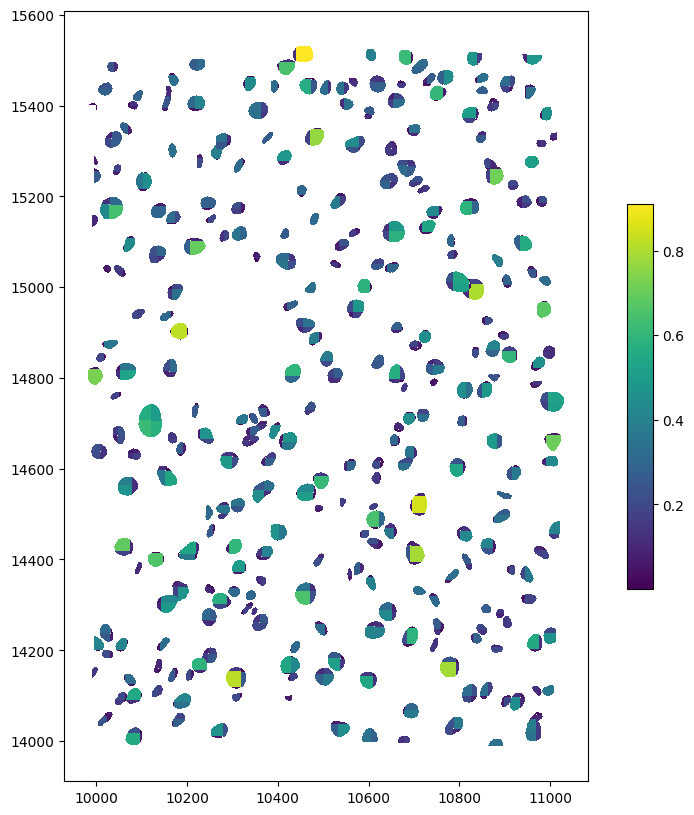

In [33]:
# Let's visualize this on a subset
# Only get intersections that are within the bounding box
bbox=(10000,11000, 14000,15500)

intersections_sub = intersections.cx[bbox[0]:bbox[1], bbox[2]:bbox[3]]
intersections_sub.set_crs("EPSG:4326", inplace=True, allow_override=True) # need to set this or it won't work

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
# Color different colors based on the percentage of nucleus area
intersections_sub.plot(column="nucleus_area_percentage", cmap="viridis", legend=False,ax=ax)

# Make legend smaller
cbar = ax.get_legend()
fig.colorbar(ax.collections[0], ax=ax, shrink=0.5, aspect=15)  # Adjust the colorbar with shrink and aspect


In [34]:
# Let's calculate some metrics
import scanpy as sc
sc.pp.calculate_qc_metrics(sdata.tables['square_008um'], inplace=True)

In [38]:
obs_008um_df

,cell_ID,in_tissue,array_row,array_col,fov_labels,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_counts,clusters,spot_id
s_008um_00301_00321-1,252560,1,301,321,Visium_HD_Liver_square_008um_labels,465,6.144186,357.143524,5.880934,23.224826,35.408061,53.104356,99.999658,0.0,0.0,0.0,919.0,0,s_008um_00301_00321-1
s_008um_00602_00290-1,504767,1,602,290,Visium_HD_Liver_square_008um_labels,392,5.973810,370.709625,5.918113,24.083579,38.085274,59.288961,100.000041,0.0,0.0,0.0,678.0,4,s_008um_00602_00290-1
s_008um_00425_00829-1,356980,1,425,829,Visium_HD_Liver_square_008um_labels,162,5.093750,233.534698,5.457603,40.956084,67.315009,100.000091,100.000091,0.0,0.0,0.0,334.0,0,s_008um_00425_00829-1
s_008um_00526_00291-1,441080,1,526,291,Visium_HD_Liver_square_008um_labels,618,6.428105,417.231415,6.036035,20.212447,31.430055,45.480842,84.609481,0.0,0.0,0.0,1120.0,5,s_008um_00526_00291-1
s_008um_00128_00278-1,107543,1,128,278,Visium_HD_Liver_square_008um_labels,471,6.156979,382.125732,5.948363,22.933717,36.710162,54.141590,99.999712,0.0,0.0,0.0,891.0,5,s_008um_00128_00278-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
s_008um_00252_00421-1,211598,1,252,421,Visium_HD_Liver_square_008um_labels,1219,7.106606,397.038300,5.986548,19.385484,28.632696,40.941796,62.475255,0.0,0.0,0.0,3518.0,0,s_008um_00252_00421-1
s_008um_00384_00793-1,322586,1,384,793,Visium_HD_Liver_square_008um_labels,204,5.323010,273.904419,5.616424,33.946837,55.392700,98.284369,100.000033,0.0,0.0,0.0,362.0,0,s_008um_00384_00793-1
s_008um_00565_00244-1,473715,1,565,244,Visium_HD_Liver_square_008um_labels,596,6.391917,378.810516,5.939672,22.157124,33.766676,49.246411,87.696175,0.0,0.0,0.0,1296.0,3,s_008um_00565_00244-1
s_008um_00353_00477-1,296292,1,353,477,Visium_HD_Liver_square_008um_labels,708,6.563856,416.003876,6.033095,19.605619,30.248578,44.412592,77.240320,0.0,0.0,0.0,1405.0,3,s_008um_00353_00477-1


In [39]:
intersections

,value,grid_id,geometry,nucleus_area,nucleus_area_percentage
0,834.0,5,"POLYGON ((37187 3672, 37188 3672, 37188 3673, ...",131.327370,0.099402
1,930.0,16,"POLYGON ((36779 3683, 36779 3682.765, 36778.77...",0.053052,0.000040
2,1643.0,6,"POLYGON ((37177 3679, 37175 3679, 37175 3680, ...",132.422427,0.100230
3,1643.0,5,"POLYGON ((37180 3692, 37180 3691, 37186 3691, ...",161.078216,0.121920
4,1846.0,2,"POLYGON ((37323 3682, 37323 3683, 37322 3683, ...",46.909662,0.035506
...,...,...,...,...,...
450783,183328.0,624193,"POLYGON ((12143 31638, 12142 31638, 12142 3163...",191.700158,0.145098
450784,183328.0,625032,"POLYGON ((12143 31651, 12143.096 31651, 12143....",0.023916,0.000018
450785,183328.0,625031,"POLYGON ((12144 31651, 12144 31652, 12145 3165...",194.793285,0.147439
450786,184364.0,624191,"POLYGON ((12239 31632, 12237 31632, 12237 3163...",296.611498,0.224505


In [40]:
obs_008um_df = sdata.tables['square_008um'].obs
obs_008um_df["spot_id"] = sdata.tables['square_008um'].obs.index

# Combine this with the intersections, to get some statistics per bin
intersections_count = intersections.merge(obs_008um_df, left_on='grid_id', right_on='cell_ID')

# Remove geometry table, then save to csv
intersections_count = intersections_count.drop(columns='geometry')
intersections_count.to_csv('intersections.csv', index=False)

This is continued in 6_2, to more easily visualize it in ggplot

### 2. Plotting with sparrow

In [45]:
sdata

SpatialData object, with associated Zarr store: /home/chananchidas/visium-hd/data/Visium_HD_Liver/Visium_HD_Liver_zarr
├── Images
│     ├── 'Visium_HD_Liver_full_image': DataTree[cyx] (3, 32447, 49192), (3, 16223, 24596), (3, 8111, 12298), (3, 4055, 6149), (3, 2027, 3074)
│     ├── 'Visium_HD_Liver_hires_image': DataArray[cyx] (3, 3958, 6000)
│     └── 'Visium_HD_Liver_lowres_image': DataArray[cyx] (3, 396, 600)
├── Labels
│     ├── 'Visium_HD_Liver_square_002um_labels': DataArray[yx] (3347, 3350)
│     ├── 'Visium_HD_Liver_square_008um_labels': DataArray[yx] (837, 838)
│     ├── 'Visium_HD_Liver_square_016um_labels': DataArray[yx] (419, 419)
│     └── 'segmentation_mask': DataArray[yx] (32447, 49192)
├── Shapes
│     ├── 'Visium_HD_Liver_square_002um': GeoDataFrame shape: (7375079, 1) (2D shapes)
│     ├── 'Visium_HD_Liver_square_008um': GeoDataFrame shape: (462269, 2) (2D shapes)
│     ├── 'Visium_HD_Liver_square_016um': GeoDataFrame shape: (115975, 1) (2D shapes)
│     └── 'segmenta

In [4]:
bbox=(10000,11000,13000,14000)

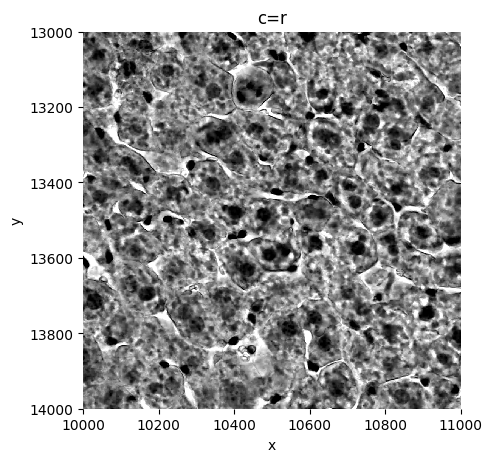

In [6]:
sp.pl.plot_image(sdata,
                 img_layer="Visium_HD_Liver_full_image",
                 crd=bbox,
                 figsize=(5,5),
                 channel="r")

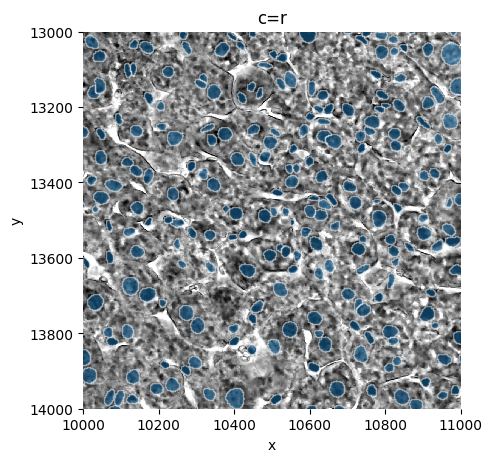

In [46]:
# Let's visualize 


sp.pl.plot_shapes(
    sdata, 
    img_layer="Visium_HD_Liver_full_image",
    shapes_layer="segmentation_boundaries",
    crd=bbox,
    figsize=(5,5) ,
    channel="r",
      )

In [21]:
# Add segmentation boundaries as labels
labels_layer = "segmentation_mask"
sdata=sp.im.rasterize( sdata, shapes_layer="segmentation_boundaries", output_layer=labels_layer, overwrite=True )

2024-11-27 14:05:34,276 - sparrow.image._manager - WARNING - No dims parameter specified. Assuming order of dimension of provided array is ((c), (z), y, x)
2024-11-27 14:05:46,437 - sparrow.image._manager - INFO - Writing results to layer 'segmentation_mask'


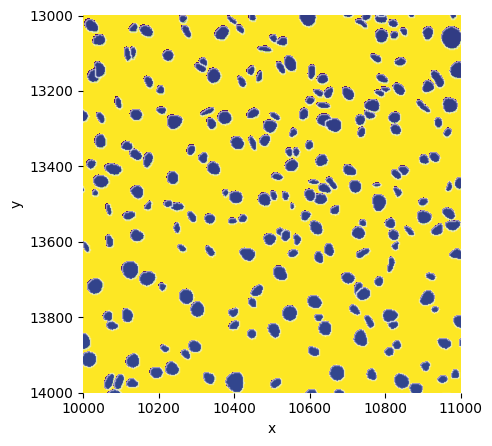

In [44]:
# sanity plot

sp.pl.plot_shapes(
    sdata, 
    labels_layer="segmentation_mask",
    shapes_layer="segmentation_boundaries",
    crd =bbox,
    figsize=(5,5),
    channel="r",
      )

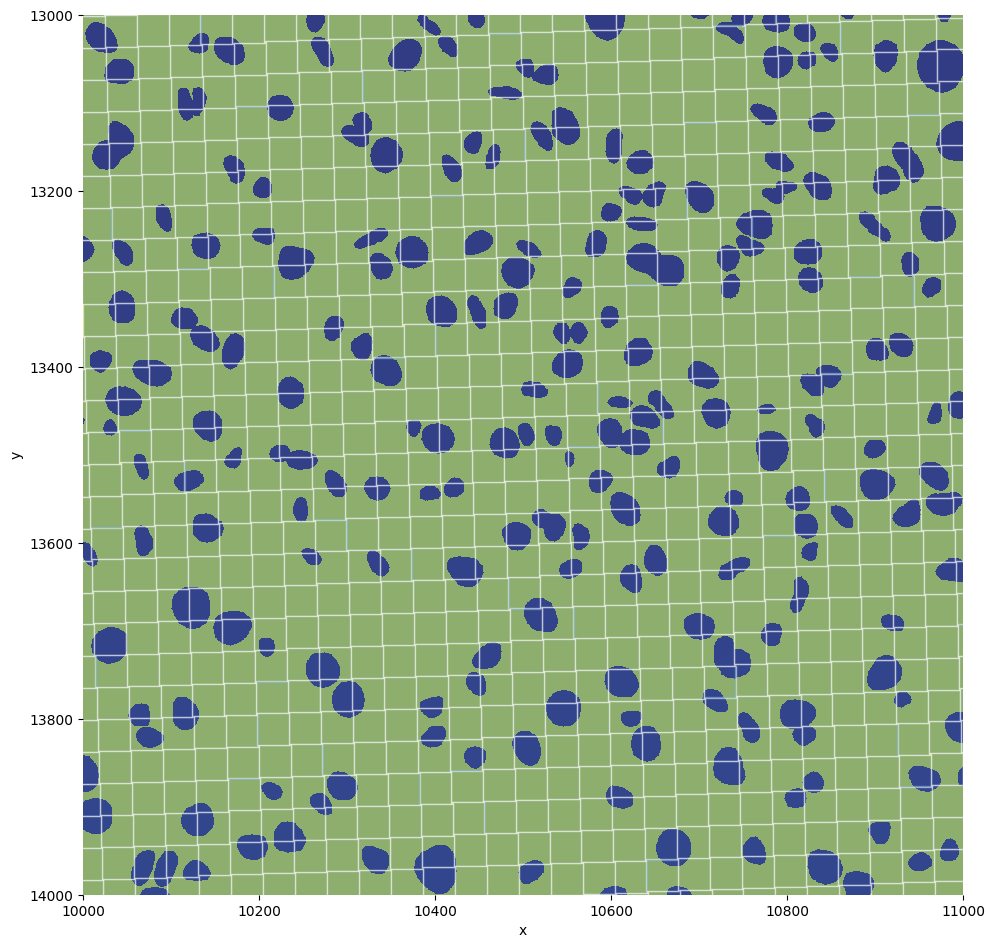

In [ ]:
# Visualizing both the grid and segmentation mask
sp.pl.plot_shapes( sdata,
                  shapes_layer= "Visium_HD_Liver_square_008um",
                  labels_layer="segmentation_mask",
                  #img_layer="Visium_HD_Mouse_Brain_full_image",
                  to_coordinate_system="global",
                  crd =bbox,
                  channel="r",
                  figsize=(10,10),
                  linewidth=1,
                  table_layer="square_008um")



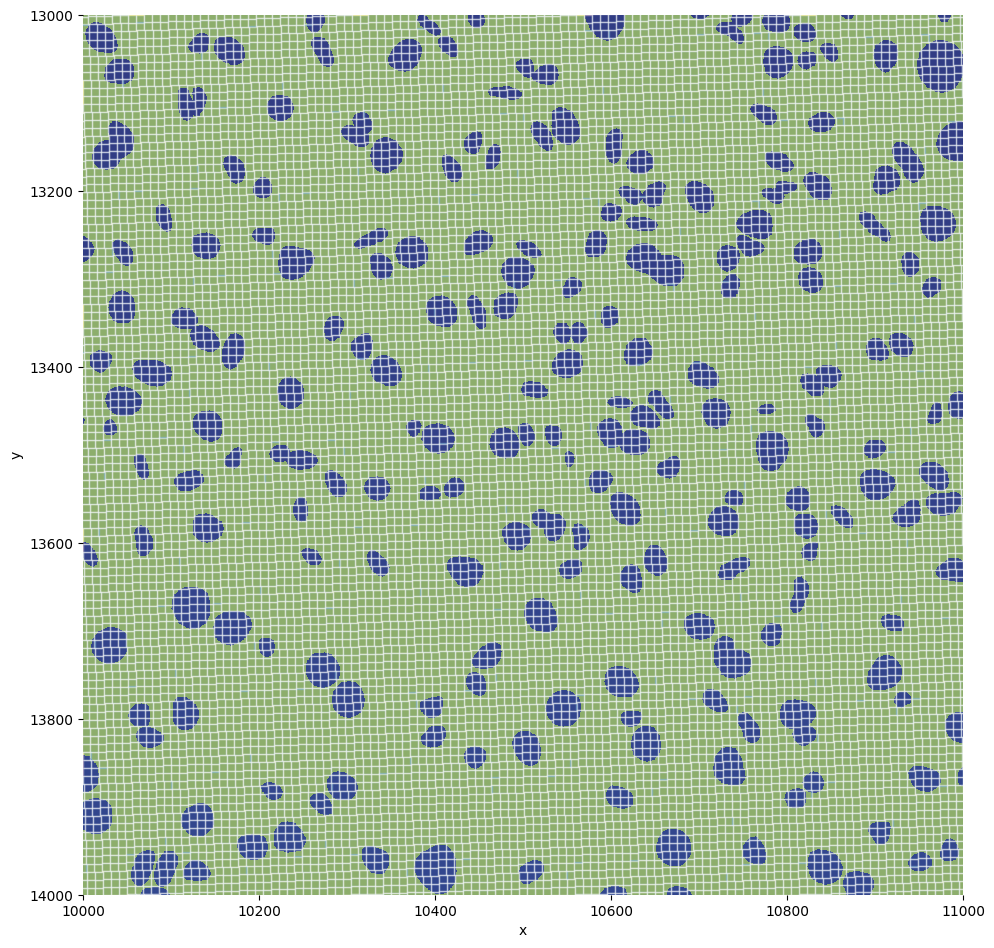

In [5]:
# Visualizing both the grid and segmentation mask
sp.pl.plot_shapes( sdata,
                  shapes_layer= "Visium_HD_Liver_square_002um",
                  labels_layer="segmentation_mask",
                  #img_layer="Visium_HD_Mouse_Brain_full_image",
                  to_coordinate_system="global",
                  crd =bbox,
                  channel="r",
                  figsize=(10,10),
                  linewidth=1,
                  table_layer="square_008um")